<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/model_experiment_TFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install

In [ ]:
!pip -q install -U kaggle mlflow dagshub lightning pytorch-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Imports + Config

In [ ]:
import os
import random
import warnings
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from google.colab import drive, userdata
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

warnings.filterwarnings("ignore")

SEED = 42
QUICK_RUN = False
VALIDATION_WEEKS = 13
FREQ = "W-FRI"
MODEL_NAME = "TFT"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
seed_everything(SEED, workers=True)

ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"
print("Accelerator:", ACCELERATOR)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Accelerator: gpu


# Paths + Kaggle Credentials

In [ ]:
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/walmart_final_project")
DATA_DIR = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / MODEL_NAME.lower()

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

kaggle_username = userdata.get("KAGGLE_USERNAME")
kaggle_token = userdata.get("KAGGLE_API_TOKEN")

if kaggle_username is None or kaggle_token is None:
    raise ValueError("Colab Secrets-ში KAGGLE_USERNAME ან KAGGLE_API_TOKEN არ ჩანს.")

os.environ["KAGGLE_USERNAME"] = kaggle_username
os.environ["KAGGLE_KEY"] = kaggle_token

print("DATA_DIR:", DATA_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("Kaggle credentials loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/walmart_final_project/data
ARTIFACT_DIR: /content/drive/MyDrive/walmart_final_project/artifacts/tft
Kaggle credentials loaded.


# Download Competition Data

In [ ]:
competition_name = "walmart-recruiting-store-sales-forecasting"
zip_path = DATA_DIR / f"{competition_name}.zip"

if not zip_path.exists():
    !kaggle competitions download -c {competition_name} -p {DATA_DIR}
else:
    print("Competition zip already exists:", zip_path)

!unzip -o {zip_path} -d {DATA_DIR}

Competition zip already exists: /content/drive/MyDrive/walmart_final_project/data/walmart-recruiting-store-sales-forecasting.zip
Archive:  /content/drive/MyDrive/walmart_final_project/data/walmart-recruiting-store-sales-forecasting.zip
  inflating: /content/drive/MyDrive/walmart_final_project/data/features.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/sampleSubmission.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/stores.csv  
  inflating: /content/drive/MyDrive/walmart_final_project/data/test.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/train.csv.zip  


# Load Data

In [ ]:
train = pd.read_csv(DATA_DIR / "train.csv.zip")
test = pd.read_csv(DATA_DIR / "test.csv.zip")
features = pd.read_csv(DATA_DIR / "features.csv.zip")
stores = pd.read_csv(DATA_DIR / "stores.csv")
sample_submission = pd.read_csv(DATA_DIR / "sampleSubmission.csv.zip")

for df in [train, test, features]:
    df["Date"] = pd.to_datetime(df["Date"])

print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("stores:", stores.shape)

train.head()

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


# Metric + TFT Feature Preparation

In [ ]:
def make_unique_id(df):
    return df["Store"].astype(str) + "_" + df["Dept"].astype(str)


def walmart_wmae(y_true, y_pred, is_holiday):
    weights = np.where(pd.Series(is_holiday).astype(bool).to_numpy(), 5, 1)
    errors = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return float(np.sum(weights * errors) / np.sum(weights))


def prepare_tft_frame(raw_train, raw_features, raw_stores):
    sales = raw_train.copy()
    sales["unique_id"] = make_unique_id(sales)
    sales = sales.rename(columns={"Date": "ds", "Weekly_Sales": "y"})

    all_ids = (
        sales[["unique_id", "Store", "Dept"]]
        .drop_duplicates()
        .sort_values("unique_id")
    )

    all_dates = pd.date_range(sales["ds"].min(), sales["ds"].max(), freq=FREQ)
    grid = all_ids.merge(pd.DataFrame({"ds": all_dates}), how="cross")

    prepared = grid.merge(
        sales[["unique_id", "ds", "y", "IsHoliday"]],
        on=["unique_id", "ds"],
        how="left",
    )

    prepared["y"] = prepared["y"].fillna(0.0)

    feature_frame = (
        raw_features
        .rename(columns={"Date": "ds"})
        .drop(columns=["IsHoliday"], errors="ignore")
    )

    prepared = prepared.merge(feature_frame, on=["Store", "ds"], how="left")
    prepared = prepared.merge(raw_stores, on="Store", how="left")

    markdown_cols = [f"MarkDown{i}" for i in range(1, 6)]

    for col in markdown_cols:
        prepared[col] = prepared[col].fillna(0.0)

    real_cols = [
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment",
        "Size",
    ] + markdown_cols

    for col in real_cols:
        prepared[col] = prepared.groupby("Store")[col].transform(lambda s: s.ffill().bfill())
        prepared[col] = prepared[col].fillna(prepared[col].median())

    prepared["time_idx"] = ((prepared["ds"] - prepared["ds"].min()).dt.days // 7).astype(int)
    prepared["weekofyear"] = prepared["ds"].dt.isocalendar().week.astype(int)
    prepared["month"] = prepared["ds"].dt.month.astype(int)
    prepared["year"] = prepared["ds"].dt.year.astype(int)

    prepared["IsHoliday"] = prepared["IsHoliday"].fillna(False).astype(str)
    prepared["Store"] = prepared["Store"].astype(str)
    prepared["Dept"] = prepared["Dept"].astype(str)
    prepared["Type"] = prepared["Type"].astype(str)
    prepared["unique_id"] = prepared["unique_id"].astype(str)

    return prepared.sort_values(["unique_id", "time_idx"]).reset_index(drop=True)

# Build TFT Dataset

In [ ]:
tft_data = prepare_tft_frame(train, features, stores)

if QUICK_RUN:
    top_ids = (
        train.assign(unique_id=make_unique_id(train))
        .groupby("unique_id")["Weekly_Sales"]
        .sum()
        .nlargest(120)
        .index
        .astype(str)
    )

    tft_data = tft_data[tft_data["unique_id"].isin(top_ids)].copy()

print("series:", tft_data["unique_id"].nunique())
print("rows:", tft_data.shape)
print("date range:", tft_data["ds"].min().date(), "to", tft_data["ds"].max().date())

tft_data.head()

series: 3331
rows: (476333, 21)
date range: 2010-02-05 to 2012-10-26


,unique_id,Store,Dept,ds,y,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,...,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,time_idx,weekofyear,month,year
0,10_1,10,1,2010-02-05,40212.84,False,54.34,2.962,0.0,0.0,...,0.0,0.0,126.442065,9.765,B,126512,0,5,2,2010
1,10_1,10,1,2010-02-12,67699.32,True,49.96,2.828,0.0,0.0,...,0.0,0.0,126.496258,9.765,B,126512,1,6,2,2010
2,10_1,10,1,2010-02-19,49748.33,False,58.22,2.915,0.0,0.0,...,0.0,0.0,126.526286,9.765,B,126512,2,7,2,2010
3,10_1,10,1,2010-02-26,33601.22,False,52.77,2.825,0.0,0.0,...,0.0,0.0,126.552286,9.765,B,126512,3,8,2,2010
4,10_1,10,1,2010-03-05,36572.44,False,55.92,2.877,0.0,0.0,...,0.0,0.0,126.578286,9.765,B,126512,4,9,3,2010


# MLflow + DagsHub

In [ ]:
DAGSHUB_USERNAME = "mgior23"
DAGSHUB_REPO_OWNER = "adzid23"
DAGSHUB_REPO_NAME = "Freeuni_ML_Walmart_Sales_Forecasting"

dagshub_token = userdata.get("DAGSHUB_TOKEN")

if dagshub_token is None:
    raise ValueError("Colab Secrets-ში DAGSHUB_TOKEN არ ჩანს.")

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = dagshub_token

mlflow.set_tracking_uri(
    f"https://dagshub.com/{DAGSHUB_REPO_OWNER}/{DAGSHUB_REPO_NAME}.mlflow"
)

if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("TFT_Training")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment: TFT_Training")

MLflow tracking URI: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow
Experiment: TFT_Training


# Log Preprocessing + Feature Setup

In [ ]:
with mlflow.start_run(run_name="TFT_Preprocessing"):
    mlflow.log_params({
        "model_family": "Deep Learning",
        "architecture": "Temporal Fusion Transformer",
        "frequency": FREQ,
        "missing_week_strategy": "fill_missing_sales_with_zero",
        "markdown_missing_filled_with_zero": True,
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
    })

    mlflow.log_metrics({
        "raw_train_rows": len(train),
        "prepared_rows": len(tft_data),
        "n_series": tft_data["unique_id"].nunique(),
        "n_dates": tft_data["time_idx"].nunique(),
    })

with mlflow.start_run(run_name="TFT_Feature_Setup"):
    mlflow.log_params({
        "static_categoricals": "Store,Dept,Type",
        "static_reals": "Size",
        "time_varying_known_categoricals": "IsHoliday",
        "time_varying_known_reals": "time_idx,weekofyear,month,year,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1-5",
        "time_varying_unknown_reals": "y",
        "target": "Weekly_Sales",
    })

print("TFT preprocessing/setup runs logged.")

🏃 View run TFT_Preprocessing at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5/runs/d7685adc8d2e4f73acef1d3047f498cb
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5
🏃 View run TFT_Feature_Setup at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5/runs/16b4c5e77fae4a78b37c198b2fb3804e
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5
TFT preprocessing/setup runs logged.


# Build TimeSeriesDataSet

In [ ]:
MAX_ENCODER_LENGTH = 52
MAX_PREDICTION_LENGTH = VALIDATION_WEEKS

training_cutoff = tft_data["time_idx"].max() - MAX_PREDICTION_LENGTH

known_reals = [
    "time_idx",
    "weekofyear",
    "month",
    "year",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
]

training_dataset = TimeSeriesDataSet(
    tft_data[tft_data["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target="y",
    group_ids=["unique_id"],
    min_encoder_length=MAX_ENCODER_LENGTH // 2,
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=MAX_PREDICTION_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=["Store", "Dept", "Type"],
    static_reals=["Size"],
    time_varying_known_categoricals=["IsHoliday"],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=["y"],
    target_normalizer=GroupNormalizer(groups=["unique_id"], center=True),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    tft_data,
    predict=True,
    stop_randomization=True,
)

BATCH_SIZE = 64 if QUICK_RUN else 128

train_loader = training_dataset.to_dataloader(
    train=True,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

valid_loader = validation_dataset.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print("training cutoff time_idx:", training_cutoff)
print("train batches:", len(train_loader))
print("valid batches:", len(valid_loader))

training cutoff time_idx: 129
train batches: 3070
valid batches: 27


# Helper Functions for TFT Training and Scoring

In [ ]:
def predict_tft_to_frame(model, dataloader, full_data, prediction_col):
    prediction_result = model.predict(
        dataloader,
        mode="prediction",
        return_index=True,
        trainer_kwargs={"accelerator": ACCELERATOR, "devices": 1},
    )

    pred_values = prediction_result.output.detach().cpu().numpy()
    index_df = prediction_result.index.reset_index(drop=True)

    rows = []

    for row_idx, row in index_df.iterrows():
        uid = str(row["unique_id"])

        for horizon_idx, yhat in enumerate(pred_values[row_idx], start=1):
            rows.append({
                "unique_id": uid,
                "time_idx": training_cutoff + horizon_idx,
                prediction_col: max(float(yhat), 0.0),
            })

    pred_frame = pd.DataFrame(rows)

    actual_frame = full_data[
        full_data["time_idx"] > training_cutoff
    ][["unique_id", "time_idx", "ds", "y", "IsHoliday"]]

    scored_frame = actual_frame.merge(
        pred_frame,
        on=["unique_id", "time_idx"],
        how="inner",
    )

    return scored_frame


def train_and_score_tft(
    run_name,
    hidden_size,
    attention_head_size,
    dropout,
    learning_rate,
    max_epochs,
    limit_train_batches,
):
    early_stop = EarlyStopping(
        monitor="val_loss",
        min_delta=1e-4,
        patience=3,
        mode="min",
    )

    lr_monitor = LearningRateMonitor(logging_interval="epoch")

    logger = CSVLogger(
        save_dir=str(ARTIFACT_DIR / "tft_logs"),
        name=run_name,
    )

    trainer = Trainer(
        max_epochs=max_epochs,
        accelerator=ACCELERATOR,
        devices=1,
        gradient_clip_val=0.1,
        callbacks=[early_stop, lr_monitor],
        logger=logger,
        enable_checkpointing=False,
        limit_train_batches=limit_train_batches,
        enable_model_summary=False,
    )

    model = TemporalFusionTransformer.from_dataset(
        training_dataset,
        learning_rate=learning_rate,
        hidden_size=hidden_size,
        attention_head_size=attention_head_size,
        dropout=dropout,
        hidden_continuous_size=max(8, hidden_size // 2),
        loss=QuantileLoss(),
        optimizer="adam",
    )

    trainer.fit(
        model,
        train_dataloaders=train_loader,
        val_dataloaders=valid_loader,
    )

    scored = predict_tft_to_frame(
        model=model,
        dataloader=valid_loader,
        full_data=tft_data,
        prediction_col="TFT",
    )

    score = walmart_wmae(
        scored["y"],
        scored["TFT"],
        scored["IsHoliday"],
    )

    return model, trainer, scored, score

# Train TFT Baseline

In [ ]:
run_suffix = "Quick" if QUICK_RUN else "Full"

BASELINE_EPOCHS = 2 if QUICK_RUN else 5
BASELINE_LIMIT_BATCHES = 20 if QUICK_RUN else 1.0

with mlflow.start_run(run_name=f"TFT_Training_Baseline_{run_suffix}") as run:
    mlflow.log_params({
        "architecture": "Temporal Fusion Transformer",
        "run_type": "baseline",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
        "max_encoder_length": MAX_ENCODER_LENGTH,
        "hidden_size": 32,
        "attention_head_size": 4,
        "dropout": 0.1,
        "learning_rate": 1e-3,
        "max_epochs": BASELINE_EPOCHS,
        "limit_train_batches": BASELINE_LIMIT_BATCHES,
        "batch_size": BATCH_SIZE,
        "n_series": tft_data["unique_id"].nunique(),
    })

    baseline_model, baseline_trainer, baseline_scored, baseline_wmae = train_and_score_tft(
        run_name=f"TFT_Training_Baseline_{run_suffix}",
        hidden_size=32,
        attention_head_size=4,
        dropout=0.1,
        learning_rate=1e-3,
        max_epochs=BASELINE_EPOCHS,
        limit_train_batches=BASELINE_LIMIT_BATCHES,
    )

    mlflow.log_metric("validation_wmae", baseline_wmae)

    baseline_path = ARTIFACT_DIR / f"baseline_state_dict_{run_suffix.lower()}.pt"
    torch.save(baseline_model.state_dict(), baseline_path)
    mlflow.log_artifact(str(baseline_path), artifact_path="model")

    baseline_scored_path = ARTIFACT_DIR / f"baseline_validation_predictions_{run_suffix.lower()}.csv"
    baseline_scored.to_csv(baseline_scored_path, index=False)
    mlflow.log_artifact(str(baseline_scored_path), artifact_path="validation")

    tft_baseline_run_id = run.info.run_id

print("Baseline TFT WMAE:", round(baseline_wmae, 4))
print("Run ID:", tft_baseline_run_id)

baseline_scored.head()

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

🏃 View run TFT_Training_Baseline_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5/runs/3163e58e1f7041df81b48dd3897ca413
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5
Baseline TFT WMAE: 1345.4466
Run ID: 3163e58e1f7041df81b48dd3897ca413


,unique_id,time_idx,ds,y,IsHoliday,TFT
0,10_1,130,2012-08-03,26390.26,False,26389.015625
1,10_1,131,2012-08-10,26320.29,False,27240.187500
2,10_1,132,2012-08-17,26752.40,False,26582.425781
3,10_1,133,2012-08-24,26804.84,False,26994.267578
4,10_1,134,2012-08-31,26083.28,False,26426.201172


# Train Tuned TFT

In [ ]:
SECOND_EPOCHS = 2 if QUICK_RUN else 6
SECOND_LIMIT_BATCHES = 20 if QUICK_RUN else 1.0

with mlflow.start_run(run_name=f"TFT_Tuning_Hidden64_LR0005_{run_suffix}") as run:
    mlflow.log_params({
        "architecture": "Temporal Fusion Transformer",
        "run_type": "hyperparameter_tuning",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
        "max_encoder_length": MAX_ENCODER_LENGTH,
        "hidden_size": 64,
        "attention_head_size": 4,
        "dropout": 0.15,
        "learning_rate": 5e-4,
        "max_epochs": SECOND_EPOCHS,
        "limit_train_batches": SECOND_LIMIT_BATCHES,
        "batch_size": BATCH_SIZE,
        "n_series": tft_data["unique_id"].nunique(),
    })

    tuned_model, tuned_trainer, tuned_scored, tuned_wmae = train_and_score_tft(
        run_name=f"TFT_Tuning_Hidden64_LR0005_{run_suffix}",
        hidden_size=64,
        attention_head_size=4,
        dropout=0.15,
        learning_rate=5e-4,
        max_epochs=SECOND_EPOCHS,
        limit_train_batches=SECOND_LIMIT_BATCHES,
    )

    mlflow.log_metric("validation_wmae", tuned_wmae)

    tuned_path = ARTIFACT_DIR / f"tuned_state_dict_{run_suffix.lower()}.pt"
    torch.save(tuned_model.state_dict(), tuned_path)
    mlflow.log_artifact(str(tuned_path), artifact_path="model")

    tuned_scored_path = ARTIFACT_DIR / f"tuned_validation_predictions_{run_suffix.lower()}.csv"
    tuned_scored.to_csv(tuned_scored_path, index=False)
    mlflow.log_artifact(str(tuned_scored_path), artifact_path="validation")

    tft_tuning_run_id = run.info.run_id

print("Tuned TFT WMAE:", round(tuned_wmae, 4))
print("Run ID:", tft_tuning_run_id)

tuned_scored.head()

INFO: `Trainer.fit` stopped: `max_epochs=6` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=6` reached.


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

🏃 View run TFT_Tuning_Hidden64_LR0005_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5/runs/fcf60ec4348f4421b944caf5904c4fcb
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5
Tuned TFT WMAE: 1544.8612
Run ID: fcf60ec4348f4421b944caf5904c4fcb


,unique_id,time_idx,ds,y,IsHoliday,TFT
0,10_1,130,2012-08-03,26390.26,False,26048.625000
1,10_1,131,2012-08-10,26320.29,False,24720.779297
2,10_1,132,2012-08-17,26752.40,False,25402.318359
3,10_1,133,2012-08-24,26804.84,False,25657.968750
4,10_1,134,2012-08-31,26083.28,False,26146.769531


# Visual Inspection

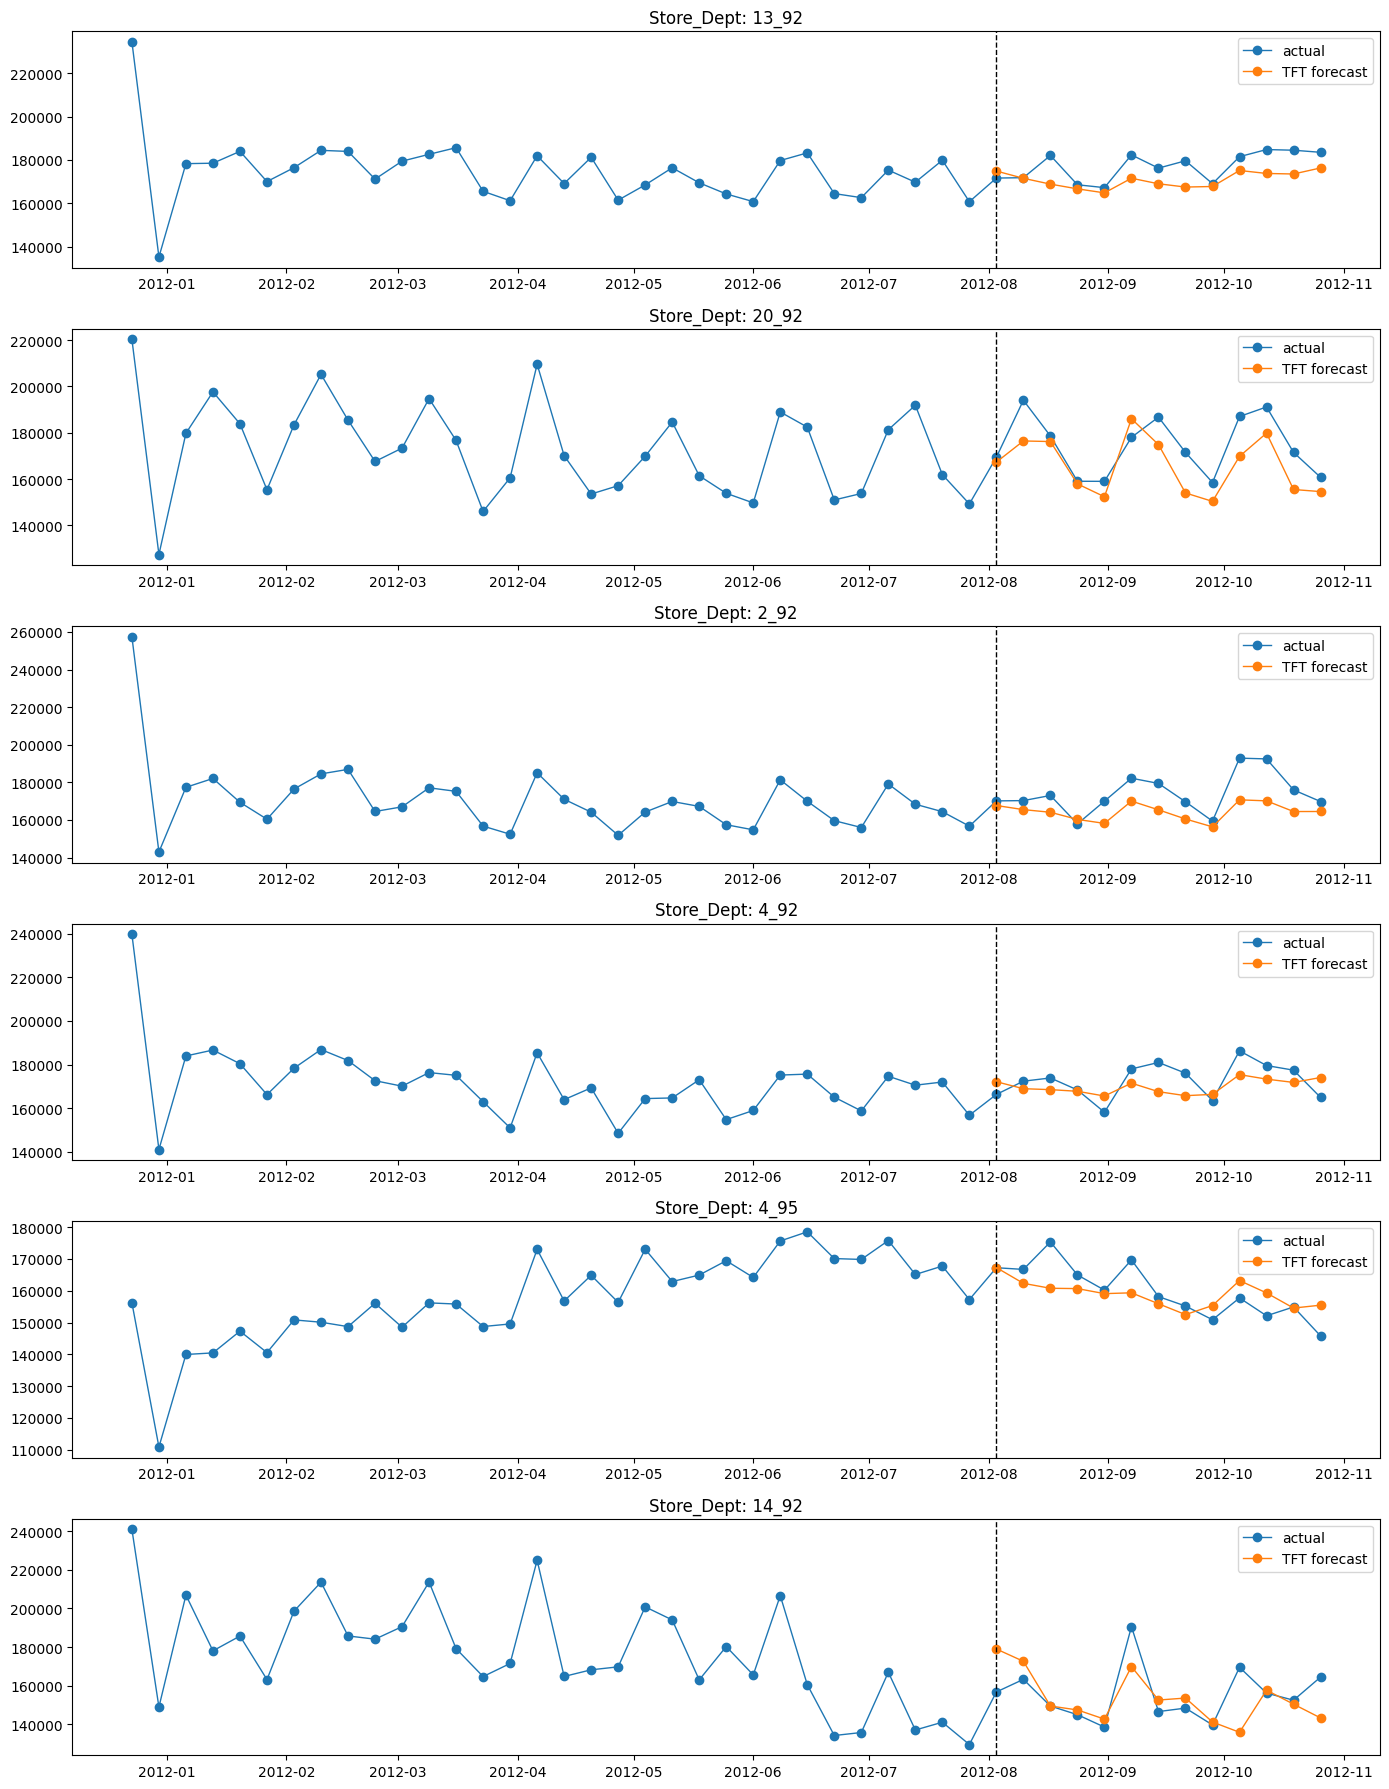

🏃 View run TFT_Validation_Visualization_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5/runs/bb5a58db15d74c73b38ff2f945700ff0
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/5
TFT validation plot logged.


In [ ]:
plot_source = tuned_scored if tuned_wmae <= baseline_wmae else baseline_scored
plot_name = "tuned" if tuned_wmae <= baseline_wmae else "baseline"

plot_ids = plot_source.groupby("unique_id")["y"].sum().nlargest(6).index

fig, axes = plt.subplots(len(plot_ids), 1, figsize=(14, 3 * len(plot_ids)), sharex=False)

if len(plot_ids) == 1:
    axes = [axes]

for ax, uid in zip(axes, plot_ids):
    hist = tft_data[tft_data["unique_id"] == uid].tail(45)
    val = plot_source[plot_source["unique_id"] == uid]

    ax.plot(hist["ds"], hist["y"], label="actual", marker="o", linewidth=1)
    ax.plot(val["ds"], val["TFT"], label="TFT forecast", marker="o", linewidth=1)
    ax.axvline(val["ds"].min(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Store_Dept: {uid}")
    ax.legend()

plt.tight_layout()

plot_path = ARTIFACT_DIR / f"{plot_name}_validation_plot_{run_suffix.lower()}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

source_run_id = tft_tuning_run_id if plot_name == "tuned" else tft_baseline_run_id

with mlflow.start_run(run_name=f"TFT_Validation_Visualization_{run_suffix}"):
    mlflow.log_param("source_run_id", source_run_id)
    mlflow.log_param("plot_source", plot_name)
    mlflow.log_artifact(str(plot_path), artifact_path="plots")

print("TFT validation plot logged.")

# Comparison Table

In [ ]:
runs = mlflow.search_runs(experiment_names=["TFT_Training"])

cols = [
    "tags.mlflow.runName",
    "metrics.validation_wmae",
    "params.run_type",
    "params.quick_run",
    "params.max_encoder_length",
    "params.hidden_size",
    "params.attention_head_size",
    "params.dropout",
    "params.learning_rate",
    "params.max_epochs",
    "params.batch_size",
    "params.n_series",
]

available_cols = [col for col in cols if col in runs.columns]

comparison = (
    runs[available_cols]
    .dropna(subset=["metrics.validation_wmae"])
    .sort_values("metrics.validation_wmae")
)

comparison

,tags.mlflow.runName,metrics.validation_wmae,params.run_type,params.quick_run,params.max_encoder_length,params.hidden_size,params.attention_head_size,params.dropout,params.learning_rate,params.max_epochs,params.batch_size,params.n_series
2,TFT_Training_Baseline_Full,1345.446601,baseline,False,52,32,4,0.1,0.001,5,128,3331
1,TFT_Tuning_Hidden64_LR0005_Full,1544.861167,hyperparameter_tuning,False,52,64,4,0.15,0.0005,6,128,3331
6,TFT_Tuning_Hidden64_LR0005_Quick,8053.303005,hyperparameter_tuning,True,52,64,4,0.15,0.0005,2,64,120
7,TFT_Training_Baseline_Quick,8079.354935,baseline,True,52,32,4,0.1,0.001,2,64,120
